In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import sys
import os

from RRAM import Plot_PostProcess as pplt

Cálculo de la resistencia serie de la RRAM

In [2]:
# region Configuracion del plot
def config_ax(ax):
    ax.grid(which='major', color='#DDDDDD', linewidth=0.8, zorder=-1)
    # Show the minor grid as well. Style it in very light gray as a thin,
    # dotted line.
    ax.grid(which='minor', color='#DEDEDE', linestyle=':', linewidth=0.5, zorder=-1)
    # Make the minor ticks and gridlines show.
    ax.minorticks_on()

    ax.tick_params(axis='both', which='both', direction='in', top=True, right=True)

def setup_plt(plt, latex=True, scaling=1):
    plt.rcParams.update(
        {
            "pgf.texsystem": "pdflatex",
            "text.usetex": latex,
            "font.family": "fourier",
            "text.latex.preamble": "\n".join([  # plots will use this preamble
                r"\usepackage[utf8]{inputenc}",
                r"\usepackage[T1]{fontenc}",
                r"\usepackage{siunitx}",
            ])
        }
    )

    SMALL_SIZE = 8 * scaling
    MEDIUM_SIZE = 10 * scaling
    BIGGER_SIZE = 12 * scaling

    plt.rc('font', size=SMALL_SIZE)             # controls default text sizes
    plt.rc('axes', titlesize=SMALL_SIZE)        # fontsize of the axes title
    plt.rc('axes', labelsize=MEDIUM_SIZE)       # fontsize of the x and y labels
    plt.rc('xtick', labelsize=SMALL_SIZE)       # fontsize of the tick labels
    plt.rc('ytick', labelsize=SMALL_SIZE)       # fontsize of the tick labels
    plt.rc('legend', fontsize=SMALL_SIZE)       # legend fontsize
    plt.rc('figure', titlesize=BIGGER_SIZE)     # fontsize of the figure title


setup_plt(plt, latex=True, scaling=1.5)

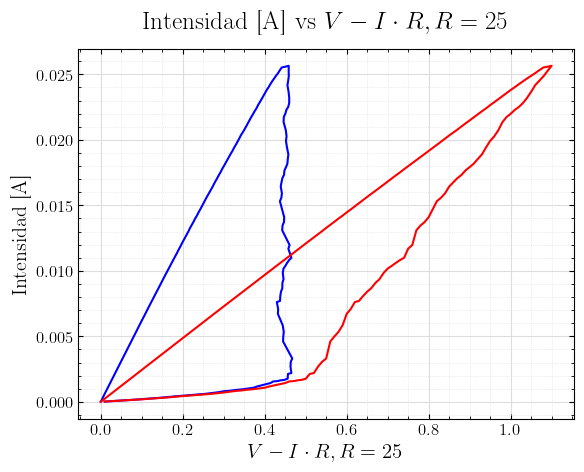

In [3]:
xlabel = 'Voltaje [V]'
ylabel = 'Intensidad [A]'

ruta_archivo_set = 'C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/Datos_Experimentales/Ciclos_Experimentales/Cycle_p_1000.txt'

try:
    # Leer datos del archivo
    data_set = np.loadtxt(ruta_archivo_set) 
except FileNotFoundError as FileNotFound_Exception:
    print("Error en la lectura de los datos de la medida: \n + FileNotFound_Exception") 
    print(f"FileNotFoundError: {FileNotFound_Exception}\n")
    
fig, axes = plt.subplots()
config_ax(axes)

# Leo los datos de la medida del donde 
x_set = data_set[:, 0]
y_set = data_set[:, 1]

resistencia = 25

v_n = x_set - y_set * resistencia

# Represento los datos

axes.set_xlabel(r'$V - I \cdot R, R = {}$'.format(resistencia))
axes.set_ylabel(ylabel)

global_tittle = r'{} vs $V - I \cdot R, R = {}$'.format(ylabel, resistencia)

axes.set_title(global_tittle, fontsize=18, pad=15)

# Represento los datos del ciclo completo
axes.plot(v_n, y_set, color='blue', label = f'R series = {resistencia}')
axes.plot(x_set, y_set, color='red', label=f'Curva original')

plt.show()
fig.savefig('C:/Users/Usuario/Documents/GitHub/RRAM_Simulation/R_series' + '.pdf', bbox_inches='tight')
plt.close(fig)